In [2]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# Pour un meilleur affichage
pd.set_option("display.max_colwidth", 200)
sns.set(style="whitegrid")

df = pd.read_csv("../data/WELFake_Dataset.csv")

df.head()


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO],No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others o...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of North Carolina [VIDEO],"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peaceful protest in order to raise issues and create change. Loretta Lynch aka Er...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid",A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in the context of presidential politics: how Louisiana Gov. Bobby Jindal traveled f...,0
4,4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range of 6,213 miles (10,000km) The weapons are perceived as part of an increasingly ag...",1


In [11]:

print("Shape:", df.shape)
print("\nColonnes:", df.columns.tolist())

Shape: (72134, 4)

Colonnes: ['Unnamed: 0', 'title', 'text', 'label']


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [13]:
df.describe(include="all")


,Unnamed: 0,title,text,label
count,72134.000000,71576,72095,72134.000000
unique,NaN,62347,62718,NaN
top,NaN,Factbox: Trump fills top jobs for his administration,,NaN
freq,NaN,14,738,NaN
mean,36066.500000,NaN,NaN,0.514404
std,20823.436496,NaN,NaN,0.499796
min,0.000000,NaN,NaN,0.000000
25%,18033.250000,NaN,NaN,0.000000
50%,36066.500000,NaN,NaN,1.000000
75%,54099.750000,NaN,NaN,1.000000


In [14]:
df.isnull().sum()


Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

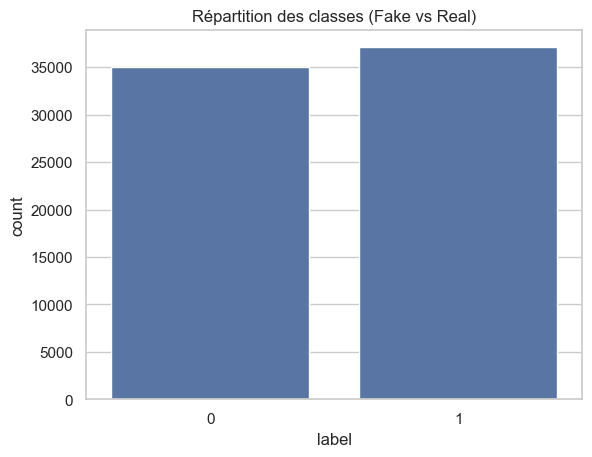

label
1    0.514404
0    0.485596
Name: proportion, dtype: float64

In [15]:
sns.countplot(x=df["label"])
plt.title("Répartition des classes (Fake vs Real)")
plt.show()

df["label"].value_counts(normalize=True)


In [16]:
# Statistiques objets (titres, sujets, dates)
df.describe(include='object').transpose()

,count,unique,top,freq
title,71576,62347,Factbox: Trump fills top jobs for his administration,14
text,72095,62718,,738


In [17]:
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
df["title_length"] = df["title"].apply(lambda x: len(str(x).split()))

df[["text_length", "title_length"]].describe()


,text_length,title_length
count,72134.000000,72134.000000
mean,540.551474,12.181052
std,625.399281,4.234335
min,0.000000,1.000000
25%,227.000000,9.000000
50%,398.000000,12.000000
75%,667.000000,14.000000
max,24234.000000,72.000000


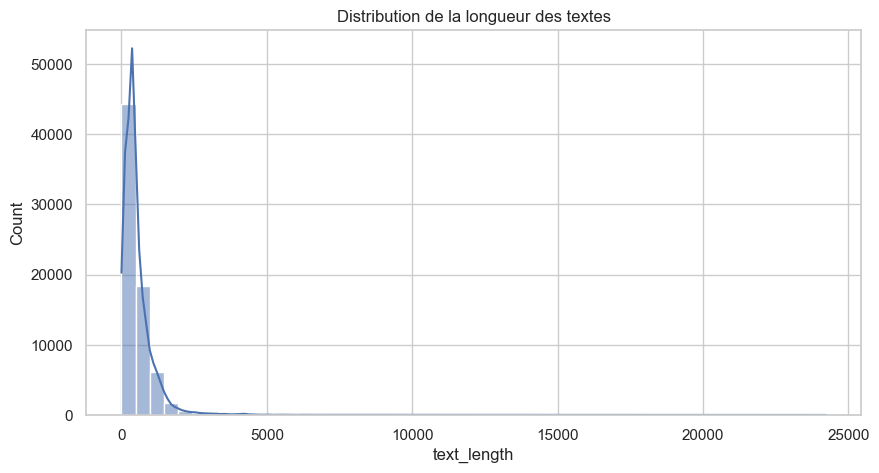

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(df["text_length"], bins=50, kde=True)
plt.title("Distribution de la longueur des textes")
plt.show()


In [19]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())

Missing values:
 Unnamed: 0        0
title           558
text             39
label             0
text_length       0
title_length      0
dtype: int64

Duplicated rows: 0


In [20]:
#Voir 10 FAKE NEWS pour comprendre leur nature
df[df["label"] == 1].sample(10)[["title", "text"]]


,title,text
45433,The Internet SAVAGES Trump After He Promotes Fox News Propaganda Again (TWEETS),"On Friday, Fox News reported that the intelligence official one of twenty people who could possibly do so according to NSA Director Mike Rogers who unmasked Trump associates with connections..."
7031,WHAT TOMI LARHEN JUST DID MADE HILLARY CLINTON’S LIFE A LIVING HELL!,"WHAT TOMI LARHEN JUST DID MADE HILLARY CLINTON’S LIFE A LIVING HELL! Tweet \nDanny Gold for Liberty Writers reports, Oh man, you gotta love Tomi Lahren. I mean forget the fact that she is easy o..."
59236,US Presidential Elections Sound a Warning of Catastrophes to Come,"US Presidential Elections Sound a Warning of Catastrophes to Come By Daily Bell Staff - November 08, 2016 \nWhat’s wrong with Hillary Clinton’s brand? … As momentous an occasion as this should be ..."
50203,BrotherJohnF Silver Update: Fake Election,"October 27, 2016 at 4:21 PM \nListen, it doesn’t matter who wins…the system can not mathematically go on the way it has…..so please dont make it sound like Trump is going to bring it down…and fuck..."
68088,TOO FUNNY! CHUCK SCHUMER Tries To Lead Liberal Chant… It’s An Epic Fail Just Like His Effort To Block Neil Gorsuch! [Video],"In recent weeks, Senate Minority Leader Chuck Schumer (D-N.Y.) has threatened to lead his caucus in filibustering President Donald Trump s nominee to the Supreme Court, Judge Neil Gorsuch, often c..."
52332,BROTHER OF FAMOUS ACTRESS PRETENDS TO BE BLACK TO GET INTO MED SCHOOL,This is a perfect example of why affirmative action should be gone! He now says he believes affirmative action is racist ya think?!Mindy Kaling s brother: I got into medical school by pretending t...
51388,WOW! RECKLESS HILLARY’S SENIOR AIDE Left Classified Documents Unattended In Hotel Room During 2010 China Trip,"Every day we learn of a new security breach or criminal act by Hillary, her closest staff members or her campaign. Every American, regardless of party affiliation should be ashamed to have such a ..."
61898,"Oregon standoff defendants found not guilty in ‘unbelievable, truly astonishing’ verdict","By Maxine Bernstein | The Oregonian/OregonLive on October 27, 2016\nA jury Thursday delivered a stunning across-the-board acquittal to the leaders and participants in the Malheur National Wildlife..."
42301,BREAKING: FL MUSLIM TERRORIST Worked For Security Company Who Quietly Transports And RELEASES Van Loads Of ILLEGAL ALIENS Away From Border For U.S. Government,"As a side note, the illegal aliens who are being dropped off across America in vans are OTM s or Other Than Mexicans. Can the mainstream media PLEASE start doing their job and exposing this corrup..."
71852,Remember That Time Hypocrite Trump Tweeted Obama Should Comply With Record Releases,"With Donald Trump handing out nicknames left and right, one nickname that has come to mind for him would be Hypocrite Trump. First of all, he doesn t apparently realize that the internet can docu..."


In [22]:
#Voir les plus grands thèmes (topic modeling)
fake_texts = df[df["label"] == 1]["text"].astype(str)

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X = tfidf.fit_transform(fake_texts)

nmf = NMF(n_components=5, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_

terms = tfidf.get_feature_names_out()

for idx, topic in enumerate(H):
    print(f"\n--- TOPIC {idx+1} ---")
    print([terms[i] for i in topic.argsort()[-15:]])



--- TOPIC 1 ---
['america', 'new', 'right', 'law', 'white', 'time', 'don', 'year', 'like', 'just', 'black', 'obama', 'police', 'said', 'people']

--- TOPIC 2 ---
['house', 'like', 'people', 'supporters', 'featured', 'image', 'just', 'white', 'said', 'election', 'republican', 'campaign', 'president', 'donald', 'trump']

--- TOPIC 3 ---
['director', 'podesta', 'wikileaks', 'state', 'server', 'foundation', 'election', 'campaign', 'investigation', 'email', 'comey', 'emails', 'fbi', 'hillary', 'clinton']

--- TOPIC 4 ---
['united', 'iran', 'obama', 'foreign', 'isis', 'government', 'nuclear', 'al', 'syrian', 'putin', 'military', 'war', 'syria', 'russian', 'russia']

--- TOPIC 5 ---
['video', 'november', 'news', 'january', 'october', 'realdonaldtrump', '2017', 'watch', '2016', 'youtube', 'www', 'https', 'pic', 'twitter', 'com']


In [23]:
# Statistiques sur les thèmes politiques
keywords = ["trump", "clinton", "hillary", "obama", "democrat", "republican", "election", "vote"]

for w in keywords:
    count = df[(df["label"] == 1) & df["text"].str.contains(w, case=False)].shape[0]
    print(f"{w:10} → {count}")


trump      → 17053
clinton    → 9713
hillary    → 9729
obama      → 9078
democrat   → 8461
republican → 8839
election   → 8864
vote       → 8135


In [24]:
#Pourcentage de FAKE NEWS politiques
political_keywords = "|".join(keywords)

political_fake = df[(df["label"] == 1) & df["text"].str.contains(political_keywords, case=False)]

percent = 100 * len(political_fake) / len(df[df["label"] == 1])
percent


70.66781652562928

In [26]:
# Génération d'un rapport automatisé avec ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="WELFake Dataset Report")
profile.to_file("report.html")


c:\Users\user\Desktop\SDIA5\fake-news-DL\FakeNews\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 474.58it/s]


In [6]:
import pandas as pd
from collections import Counter
import re

df = pd.read_csv("../data/WELFake_Dataset.csv")

def extract_keywords(series, n=40):
    # Convertir en string et remplacer NaN
    cleaned_series = series.fillna("").astype(str)
    
    text = " ".join(cleaned_series).lower()
    words = re.findall(r"[a-zA-Z]+", text)

    stopwords = {
        "the","and","for","that","with","this","from","have","was","were","been","has",
        "but","are","not","you","your","will","about","they","their","just","what","when",
        "would","could","should","into","over","after","before","all","more","most","said",
        "news","breaking","story","fake","real","http","www"
    }

    words = [w for w in words if w not in stopwords and len(w) > 3]

    return Counter(words).most_common(n)

fake_keywords = extract_keywords(df[df["label"] == 0]["text"])
real_keywords = extract_keywords(df[df["label"] == 1]["text"])

fake_keywords[:30], real_keywords[:30]


([('trump', 107213),
  ('president', 51302),
  ('which', 45574),
  ('people', 41792),
  ('state', 38873),
  ('also', 36609),
  ('there', 36151),
  ('some', 31909),
  ('states', 31669),
  ('than', 31470),
  ('government', 30110),
  ('other', 29575),
  ('reuters', 29342),
  ('house', 28578),
  ('clinton', 28570),
  ('year', 28154),
  ('united', 27740),
  ('last', 26638),
  ('republican', 26548),
  ('like', 24796),
  ('them', 24037),
  ('told', 23991),
  ('campaign', 23383),
  ('time', 23335),
  ('first', 23300),
  ('obama', 22956),
  ('party', 22895),
  ('years', 22103),
  ('against', 21571),
  ('many', 21358)],
 [('trump', 107037),
  ('people', 48677),
  ('clinton', 45517),
  ('there', 39633),
  ('president', 39081),
  ('which', 36607),
  ('like', 31794),
  ('hillary', 31675),
  ('obama', 28673),
  ('also', 28562),
  ('them', 27923),
  ('other', 27079),
  ('because', 26374),
  ('than', 26340),
  ('time', 26191),
  ('even', 25871),
  ('state', 25361),
  ('donald', 25083),
  ('only', 2468